# `run_figures.ipynb` — standardized paper figures

Regenerate the paper's figures through the pipeline in the package's house style.
`hiddenstructure.paper.generate_paper_figures` reproduces **Figs 2–7** for the
Community Alignment dataset; the lower cells show how to build individual figures
for any dataset / mechanism set.

`dataset → externalities / mechanism → figures`


## Setup

In [1]:
import sys, os
sys.path.insert(0, "src")
# os.environ["HS_DATA_ROOT"] = "/Users/michellesi/Desktop/harvard/distortion"

%config InlineBackend.figure_formats = ['png']
import hiddenstructure as hs
from hiddenstructure import pipeline, figures, welfare, paper
from hiddenstructure.mechanisms import (
    Utilitarian, RLHF, Strategyproof, BoundedHarm, PublicSpirit)
from IPython.display import Image, display
print("data root:", hs.config.data_root())

data root: /Users/michellesi/Desktop/harvard/distortion


## Config

`OUTDIR` — where figures are written (as `<dataset>_<figure>.png`).
`STRATIFIED_N` — agent cap for the leave-one-out-heavy Γ heatmaps (Figs 3, 5, 7);
Figs 2, 4, 6 run on the full population (`full=True`).

In [2]:
DATASET      = "Community Alignment"
OUTDIR       = "figures"
STRATIFIED_N = 100

## Paper figures (Figs 2–7)

One call fits the models and writes every paper figure. It runs the LOO-heavy Γ
heatmaps on a `STRATIFIED_N`-agent sample and the welfare / group-averaged figures
on the full population, matching each figure's N in the paper.

In [3]:
pf = paper.generate_paper_figures(
    DATASET, stratified_n=STRATIFIED_N, full=True, outdir=OUTDIR, verbose=True)
for key, paths in pf.manifest.items():
    print(f"{key:32s} -> {paths[0].name}")

[Γ run, stratified N=100]


Utilitarian       |Γ|∈[1.259e-08, 8.989e-03]  diag μ +1.123e-03  off-diag μ -8.613e-06
RLHF              |Γ|∈[1.177e-07, 1.131e-02]  diag μ +1.444e-03  off-diag μ +1.520e-06


  Bounded harm  ε=0.05 LOO: cache hit
Bounded harm  ε=0.05  |Γ|∈[3.104e-19, 1.784e-01]  diag μ +8.469e-04  off-diag μ -2.187e-04
  Bounded harm  b=-0.005 LOO: cache hit
Bounded harm  b=-0.005  |Γ|∈[2.164e-10, 1.786e-01]  diag μ +5.892e-04  off-diag μ -2.272e-04


  saved fig3_gamma_util_vs_bh_abs


  saved fig5_gamma_util_vs_bh_eps


...

  Moral Machine: cache
  Community Alignment: cache


  saved fig8_preference_distribution


  saved fig9_expected_welfare_subset


  saved fig10_welfare_variance


  saved fig11_per_agent_welfare
fig3_gamma_util_vs_bh_abs        -> community_alignment_fig3_gamma_util_vs_bh_abs.png
fig5_gamma_util_vs_bh_eps        -> community_alignment_fig5_gamma_util_vs_bh_eps.png
fig7_perperson_vs_group          -> community_alignment_fig7_perperson_vs_group.png
fig6_group_averaged_util_vs_rlhf -> community_alignment_fig6_group_averaged_util_vs_rlhf.png
fig2_welfare_distribution        -> community_alignment_fig2_welfare_distribution.png
fig4_welfare_vs_beta             -> community_alignment_fig4_welfare_vs_beta.png
fig8_preference_distribution     -> community_alignment_fig8_preference_distribution.png
fig9_expected_welfare_subset     -> community_alignment_fig9_expected_welfare_subset.png
fig10_welfare_variance           -> community_alignment_fig10_welfare_variance.png
fig11_per_agent_welfare          -> community_alignment_fig11_per_agent_welfare.png


### View them inline

fig3_gamma_util_vs_bh_abs


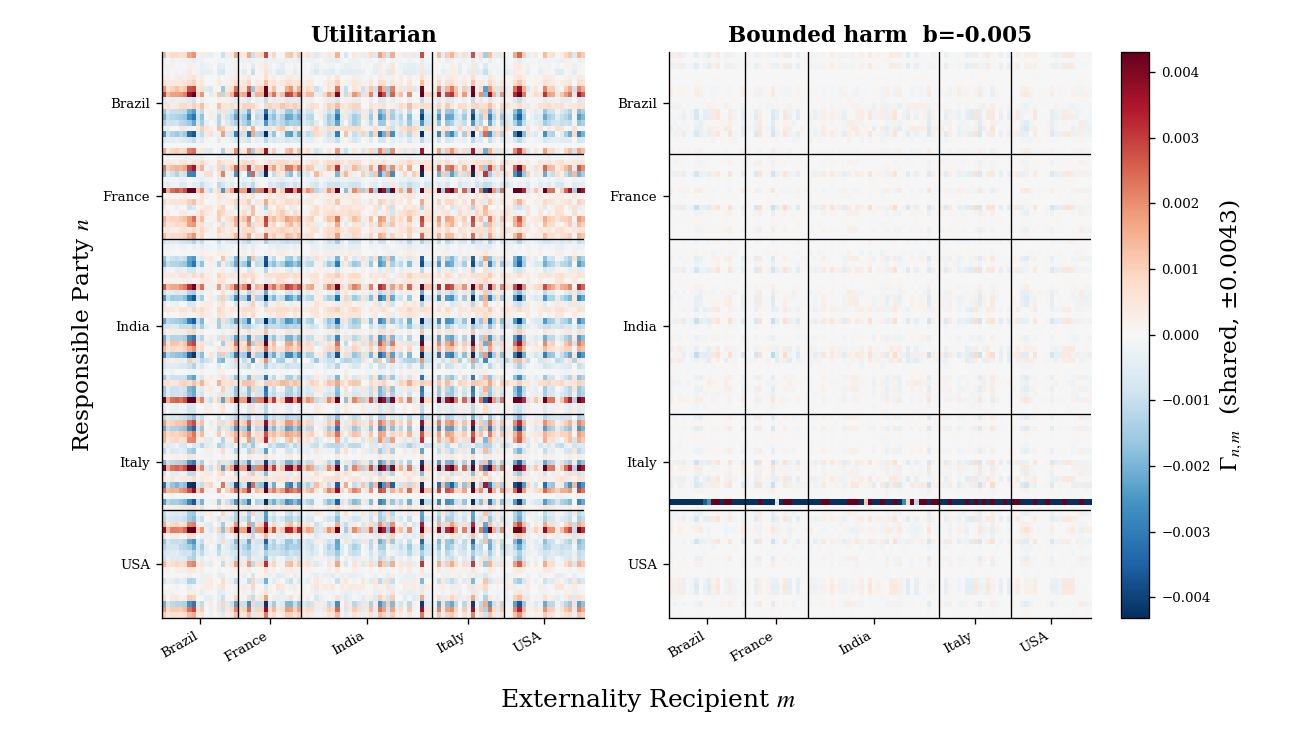

fig5_gamma_util_vs_bh_eps


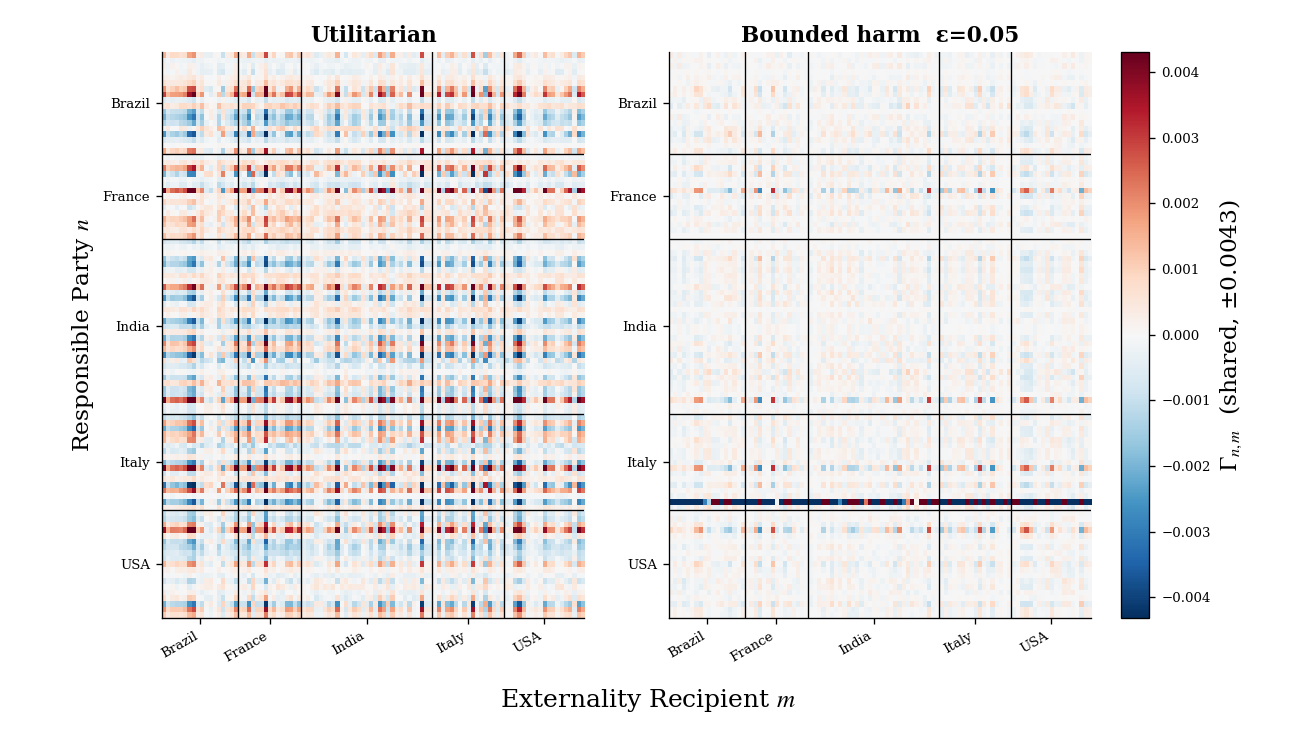

fig7_perperson_vs_group


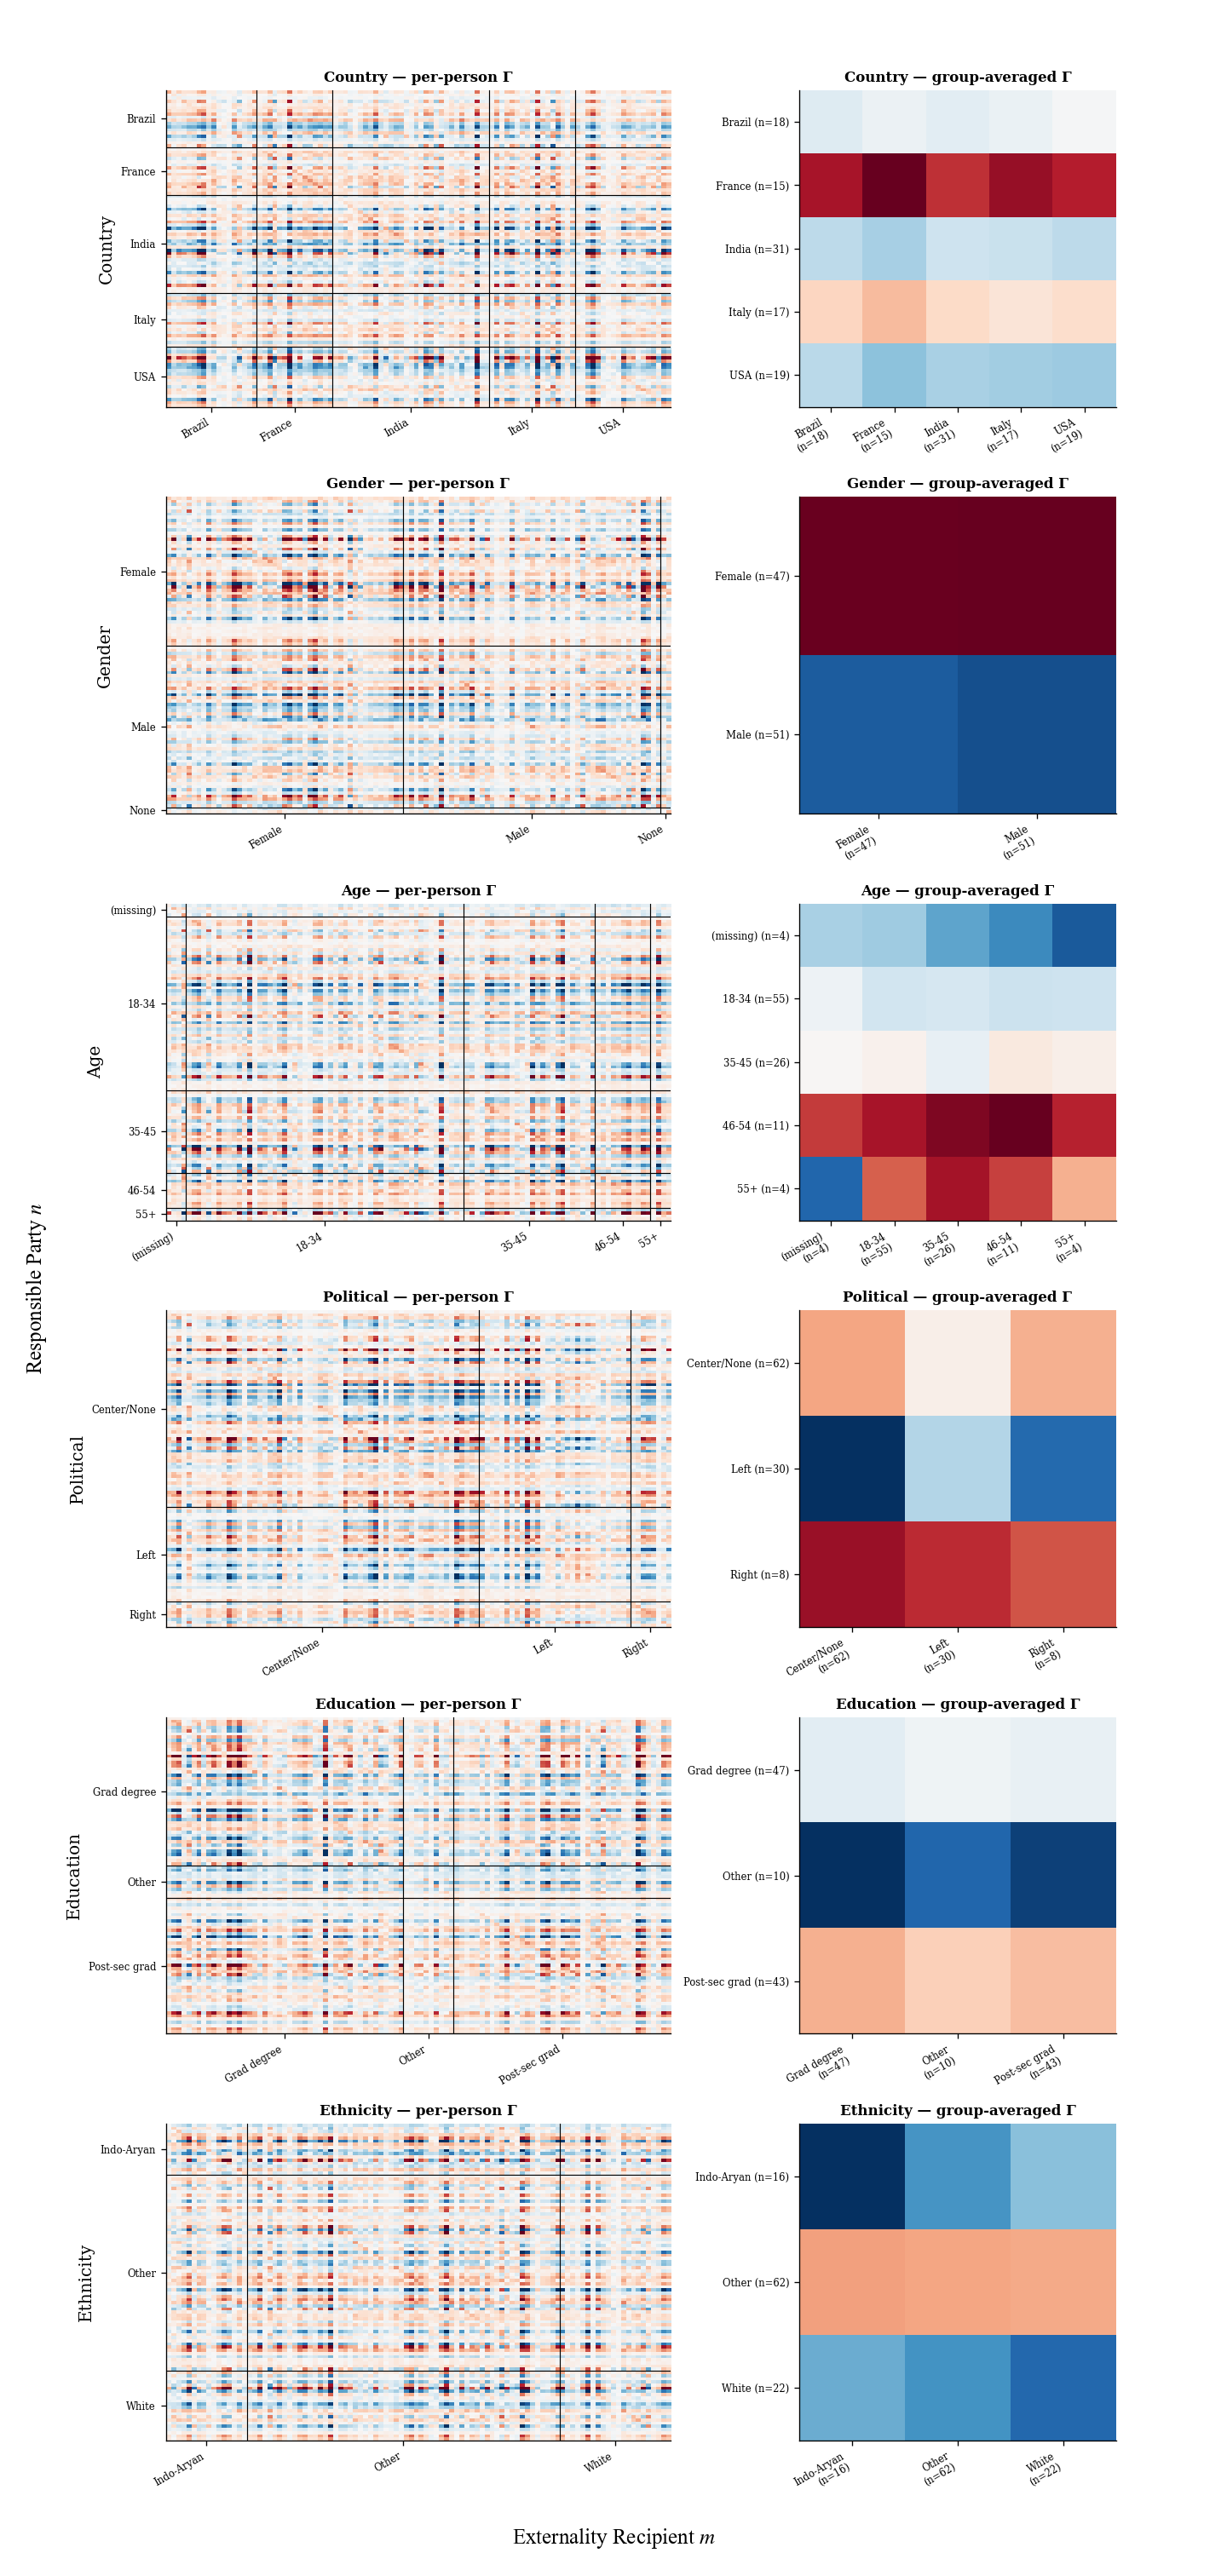

fig6_group_averaged_util_vs_rlhf


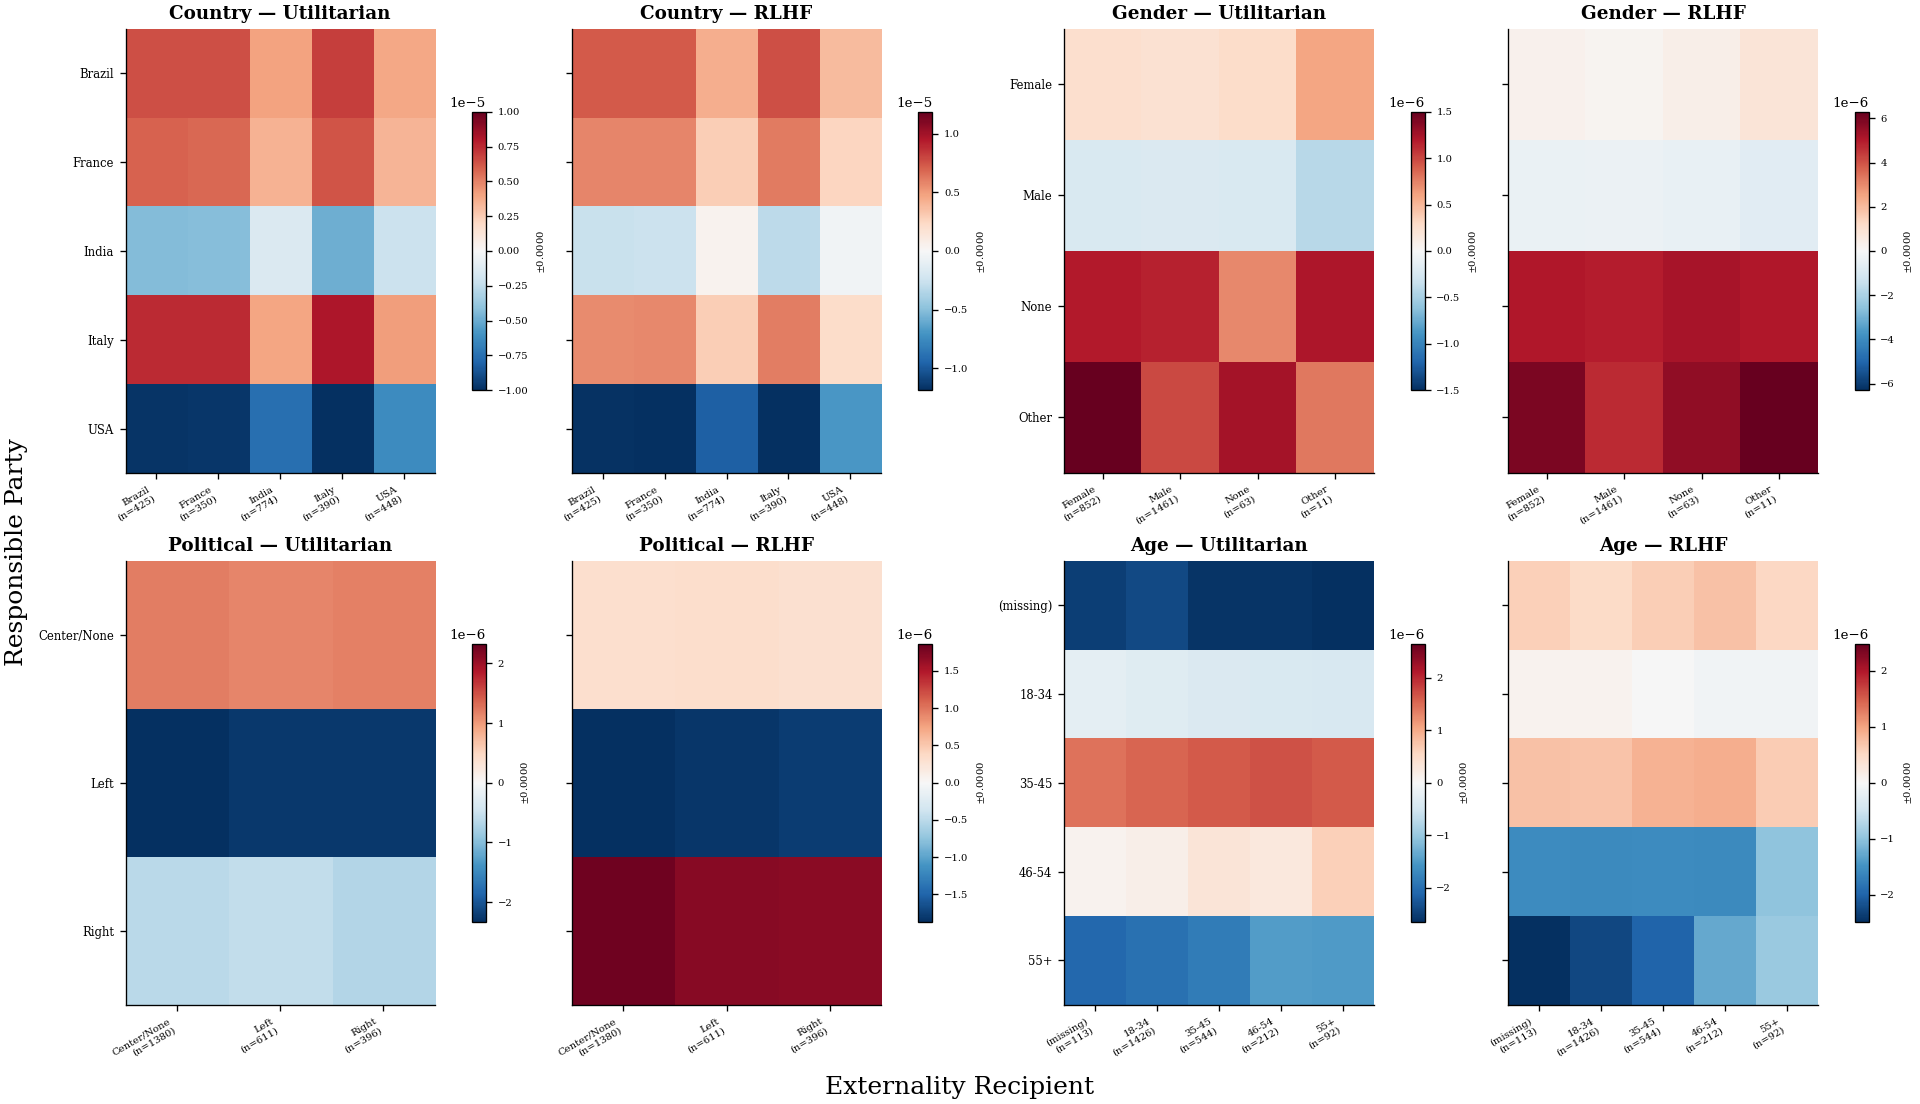

fig2_welfare_distribution


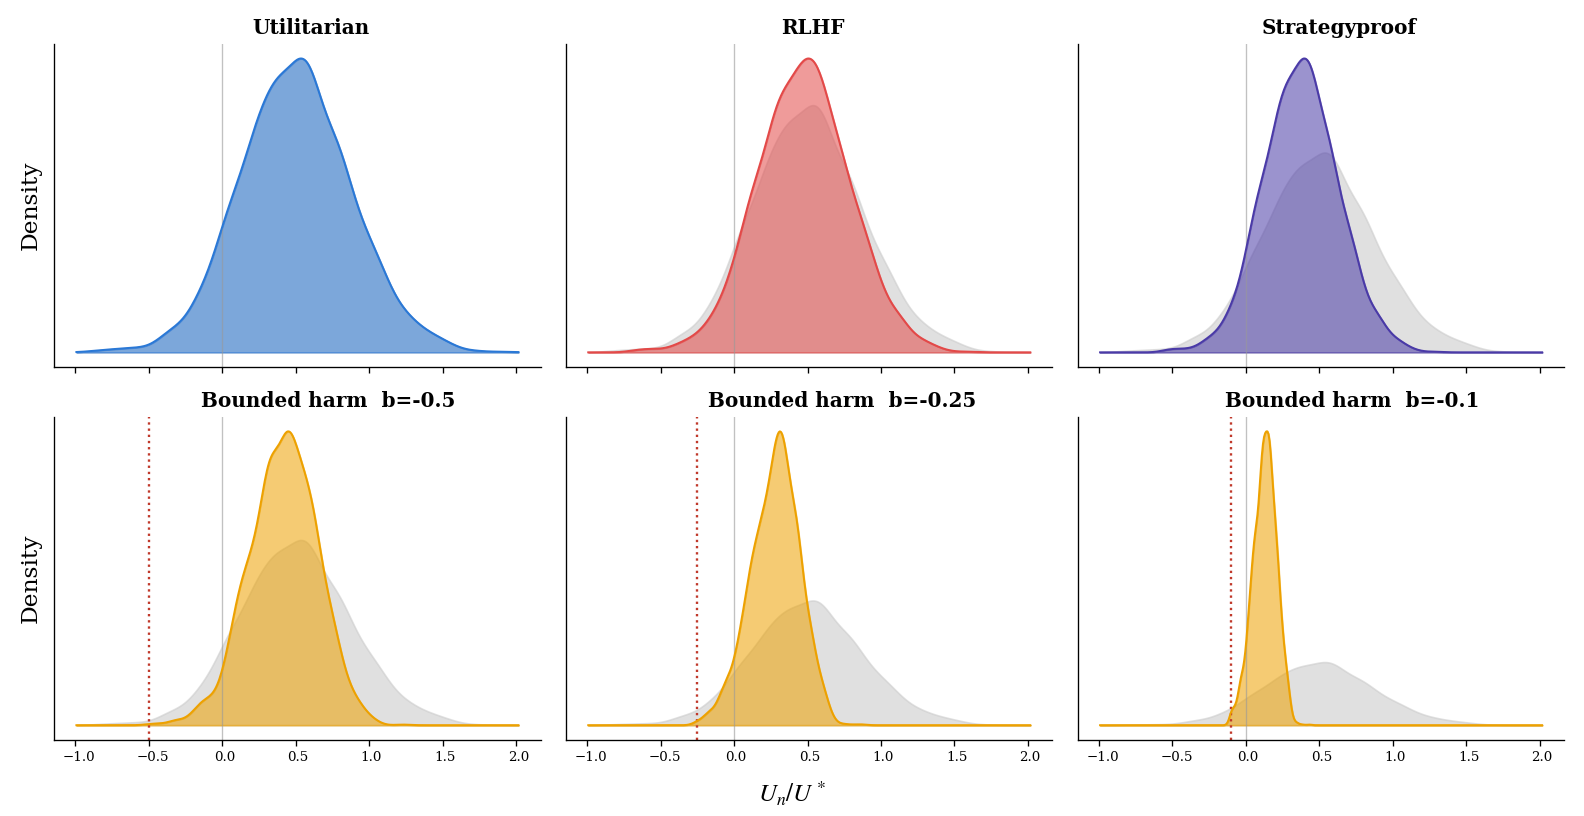

fig4_welfare_vs_beta


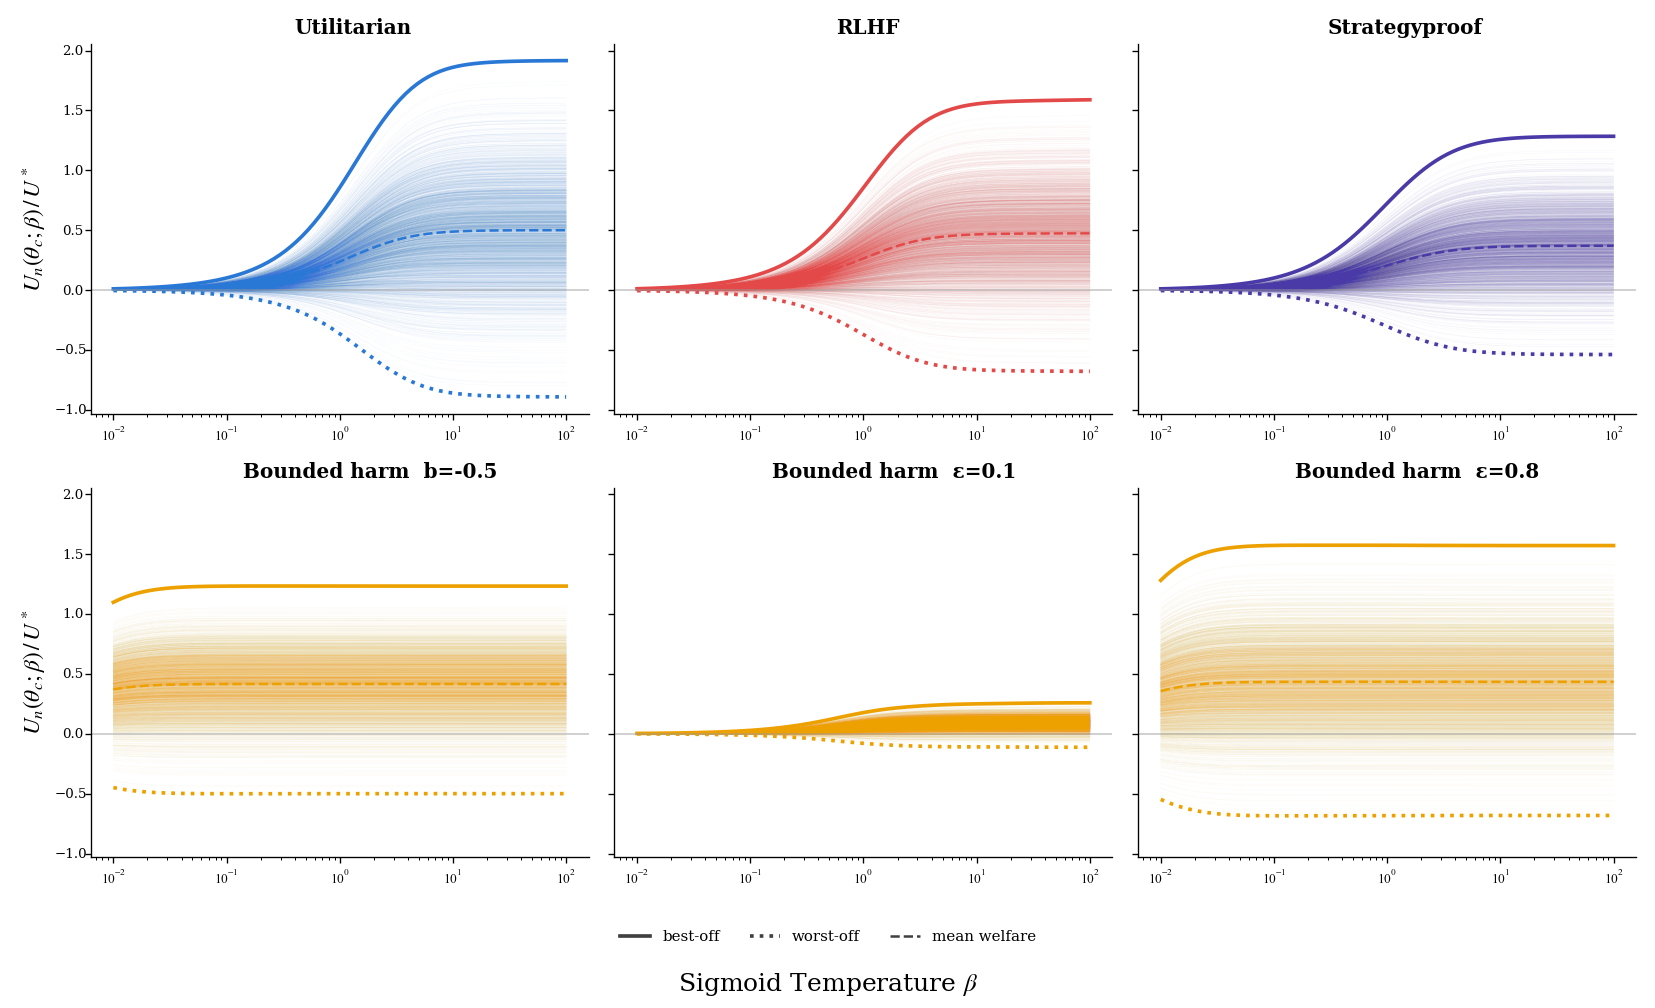

fig8_preference_distribution


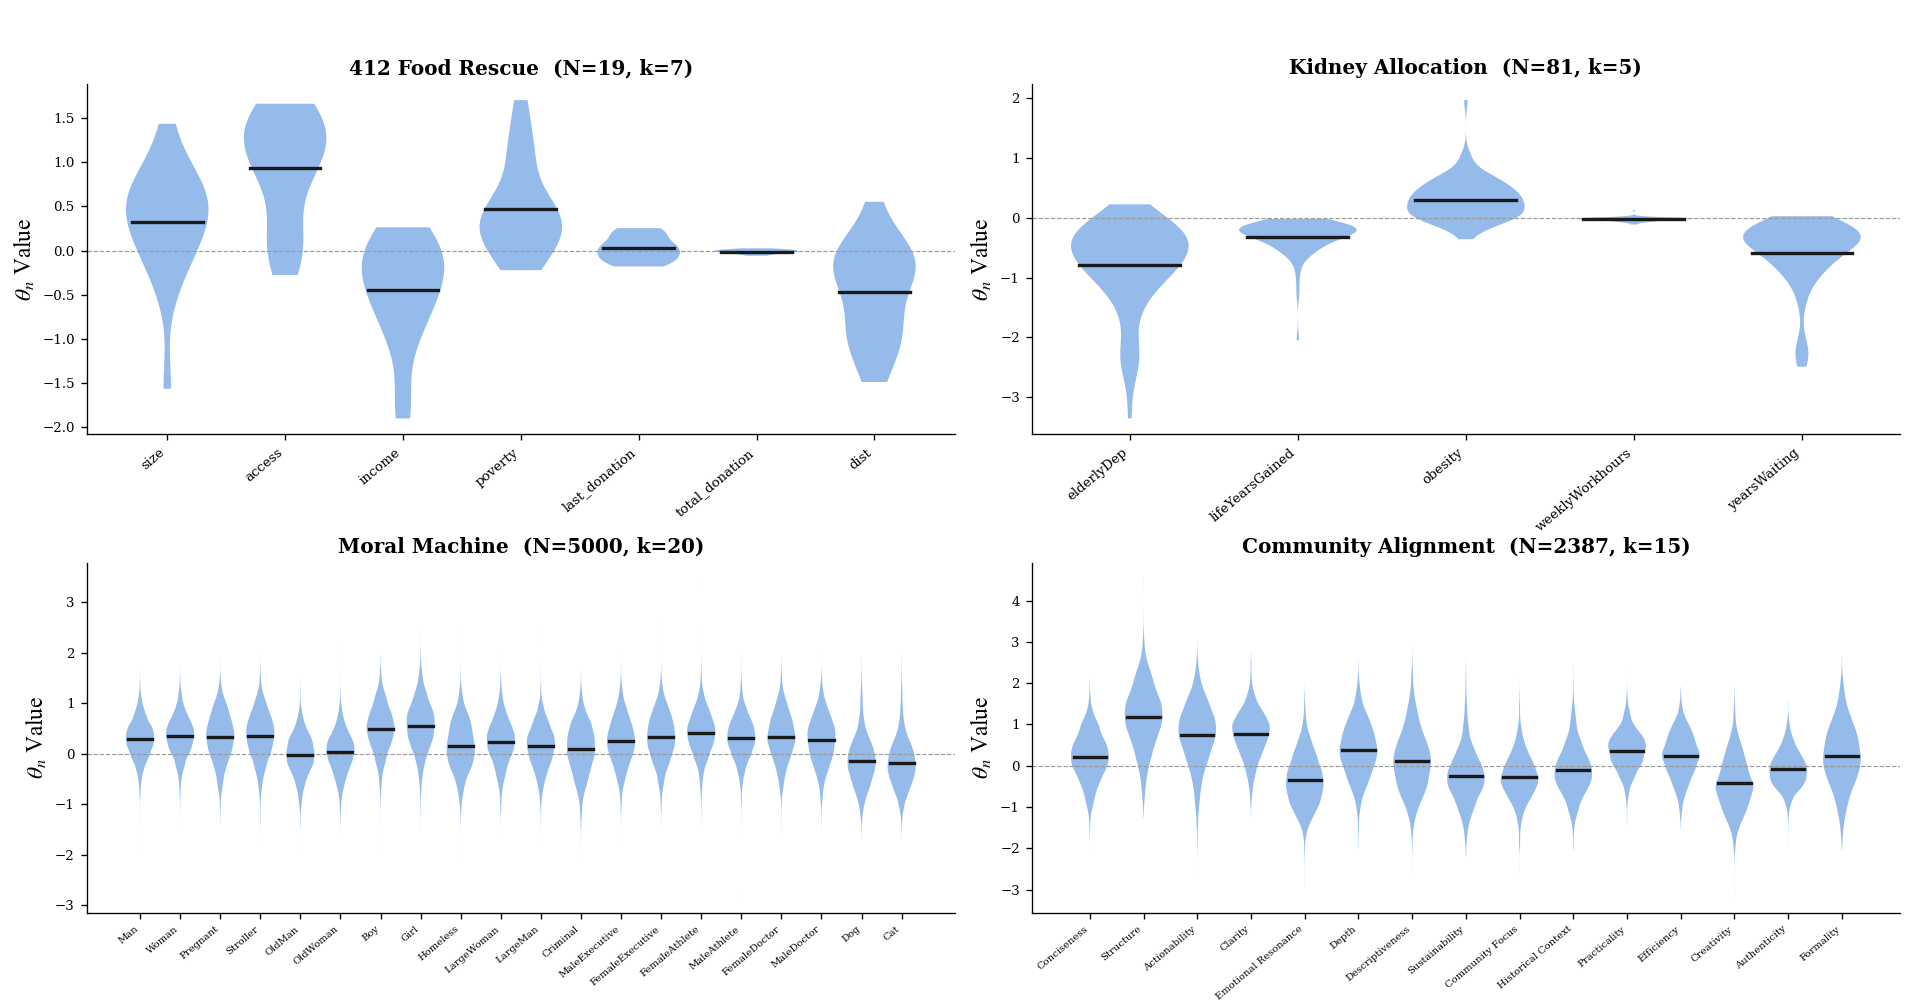

fig9_expected_welfare_subset


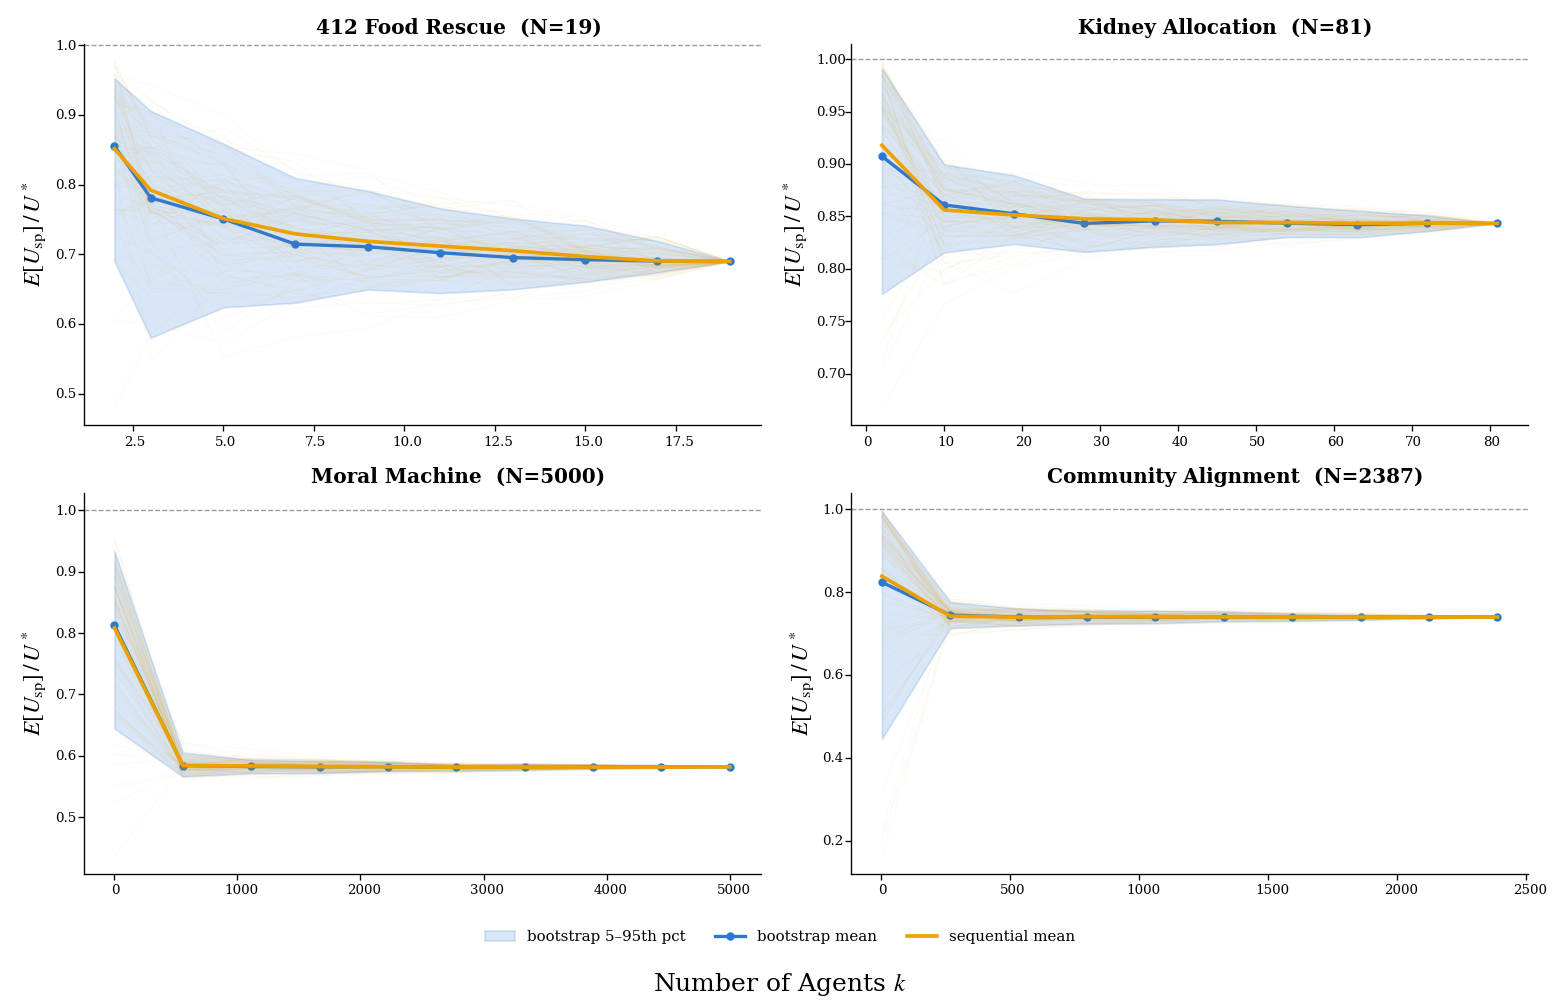

fig10_welfare_variance


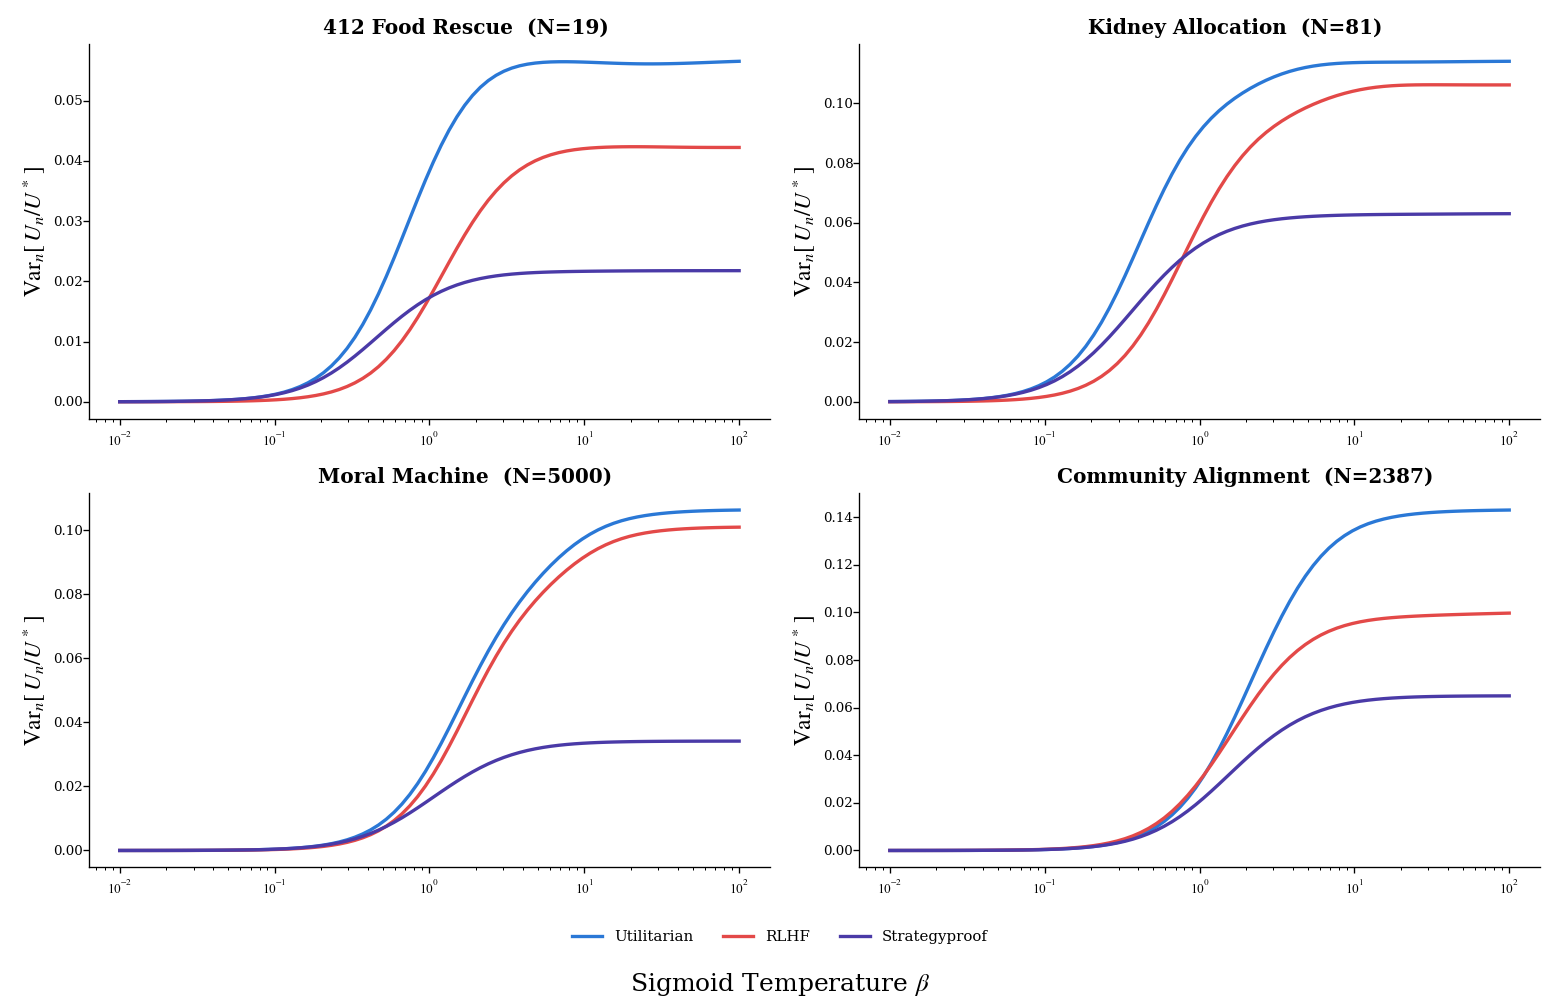

fig11_per_agent_welfare


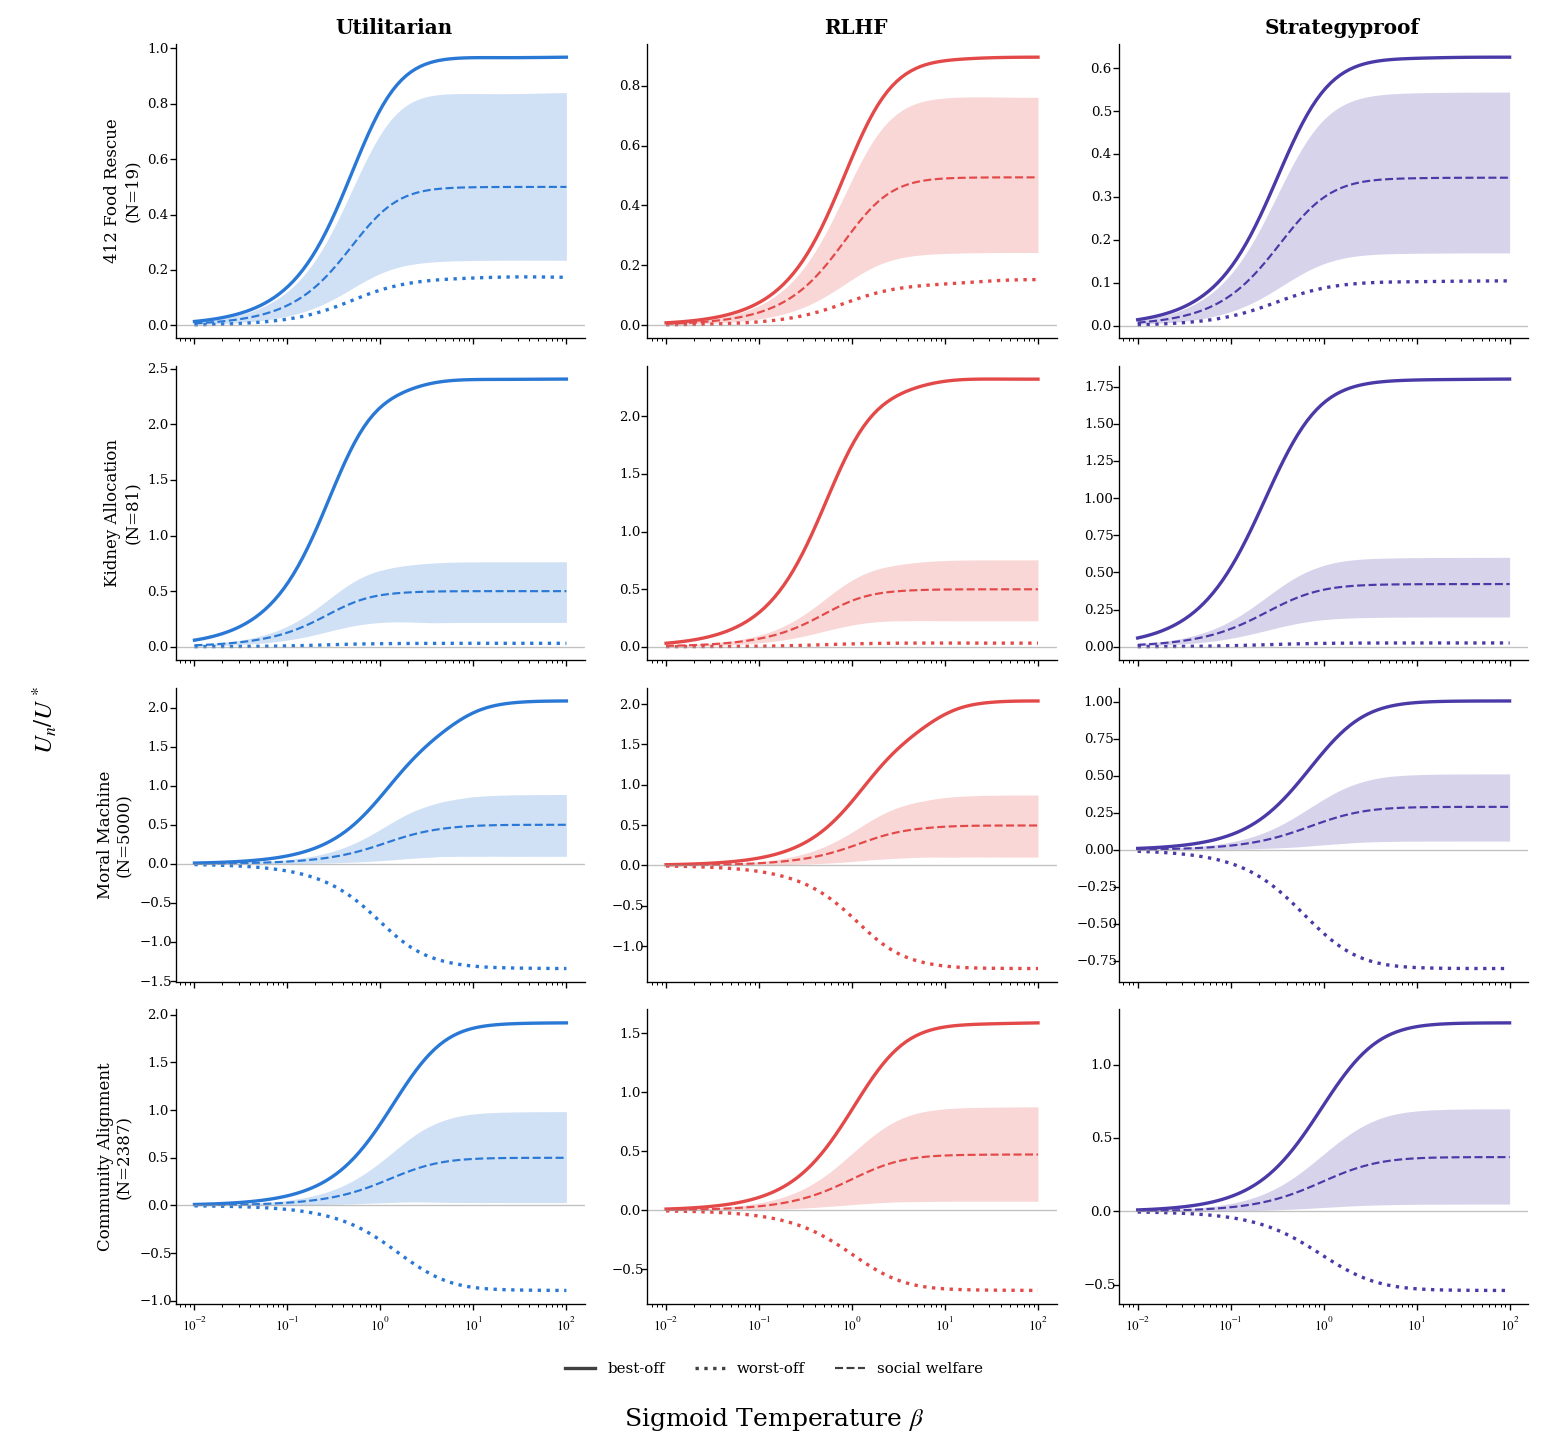

In [4]:
for key, paths in pf.manifest.items():
    png = next(p for p in paths if p.suffix == ".png")
    print(key); display(Image(filename=str(png)))

## Build individual figures — reusing the fitted models

`generate_paper_figures` returns the fitted objects (`pf.run` = stratified-N Γ run,
`pf.modelF` = full-population model), so the extra figures below **reuse** them
rather than refitting:

- **Externality standard set** (gamma_per_agent, group_averaged, mechanism_summary,
  externality_ranking) from the Γ run already computed:

In [5]:
figures.generate_all(pf.run, outdir=OUTDIR)
figures.fig_mechanism_summary(pf.run); None

- **Welfare–protection frontier** (public-spirit γ, or `bounded_harm` ε), on the same model:

In [6]:
fr = welfare.protection_frontier(pf.run.model, "public_spirit")
welfare.fig_protection_frontier(fr); None

- **The 2-D impact-space schematic** (dataset-independent):

In [7]:
figures.fig_impact_space_2d(); None

### House style / customization

- `figures.MECH_COLORS` — fixed, CVD-validated mechanism palette (blue=util,
  red=RLHF, violet=strategyproof, amber=bounded harm, green=public spirit).
- `figures.GAMMA_CMAP` — diverging colormap for Γ heatmaps (`RdBu_r`).
- `figures.PAPER_RC` — fonts, sizes; PNG @ 300 dpi by default.
- `figures.save_fig(fig, name, outdir, formats)` — save any figure the same way
  (`formats=("png","svg")` if you want vector output too).

Add a paper figure: write a `fig_*` builder (wrap the body in
`with figures.use_paper_style():`) and, for the Γ standard set, register it in
`figures.STANDARD_FIGURES`; welfare figures live in `welfare.py`.